In [4]:
import pandas as pd
import os
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def create_boxplots_wrt_gamma(gamma_value, path, output_dir="plots"):
    """Create a single boxplot for a specific gamma value using efficient Polars operations.
    
    Parameters:
    -----------
    gamma_value : float
        The gamma value to filter data for
    path : str
        Path to the directory containing parquet files
    output_dir : str
        Directory to save the output plot
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Find all chunk files
    chunk_files = sorted([f for f in os.listdir(path) 
                         if f.startswith('combined_simulation_results_epoch') and f.endswith('.parquet')])
    
    # Initialize empty lists to store the differences
    plot_data = {
        'sigma': [],
        'diff_dis_out_in': [],
        'diff_re_out_in': [],
        'diff_dis_out_re_out': [],
        'diff_dis_in_re_in': []
    }
    
    # Process each chunk separately
    for chunk in chunk_files:
        # Read and process one chunk at a time
        df = pl.scan_parquet(os.path.join(path, chunk)).filter(pl.col('gamma') == gamma_value)
        
        # Calculate derived values
        df = df.with_columns([
            (pl.col('final_x') * pl.col('final_price') + pl.col('final_y') + pl.col('fees_out')).alias('vout_dis'),
            (pl.col('final_x') * pl.col('final_price') + pl.col('final_y') + pl.col('fees_inc')).alias('vinc_dis'),
            (pl.col('final_xout') * pl.col('final_price') + pl.col('final_yout')).alias('vout_re'),
            (pl.col('final_xinc') * pl.col('final_price') + pl.col('final_yinc')).alias('vinc_re')
        ])
        
        # Calculate differences
        df = df.with_columns([
            (pl.col('vout_dis') - pl.col('vinc_dis')).alias('diff_dis_out_in'),
            (pl.col('vout_re') - pl.col('vinc_re')).alias('diff_re_out_in'),
            (pl.col('vout_dis') - pl.col('vout_re')).alias('diff_dis_out_re_out'),
            (pl.col('vinc_dis') - pl.col('vinc_re')).alias('diff_dis_in_re_in')
        ])
        
        # Select only the needed columns and collect
        chunk_data = df.select(['sigma', 'diff_dis_out_in', 'diff_re_out_in', 
                              'diff_dis_out_re_out', 'diff_dis_in_re_in']).collect()
        
        # Append to plot data
        for col in plot_data:
            plot_data[col].extend(chunk_data[col].to_list())
    
    # Convert to pandas only once for plotting
    plot_df = pd.DataFrame(plot_data)
    
    # Get unique gamma values for tick labels
    unique_sigmas = sorted(plot_df['sigma'].unique())
    tick_positions = np.arange(len(unique_sigmas))
    tick_labels = [f'{sigma:.3f}' if i % 3 == 0 else '' for i, sigma in enumerate(unique_sigmas)]
    
    # Create the plot
    plt.figure(figsize=(15, 8))
    plt.title(f'Distribute Out - Distribute In for γ = {gamma_value}', fontsize=16)
    
    # Create single boxplot
    sns.boxplot(data=plot_df, x='sigma', y='diff_dis_out_in')
    plt.xlabel('sigma (σ)')
    plt.ylabel('Value Difference')
    plt.grid(True, axis='y')
    plt.xticks(tick_positions)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save the plot
    plt.savefig(f"{output_dir}/boxplot_sigma_{gamma_value}.png", dpi=500)
    
    plt.show()

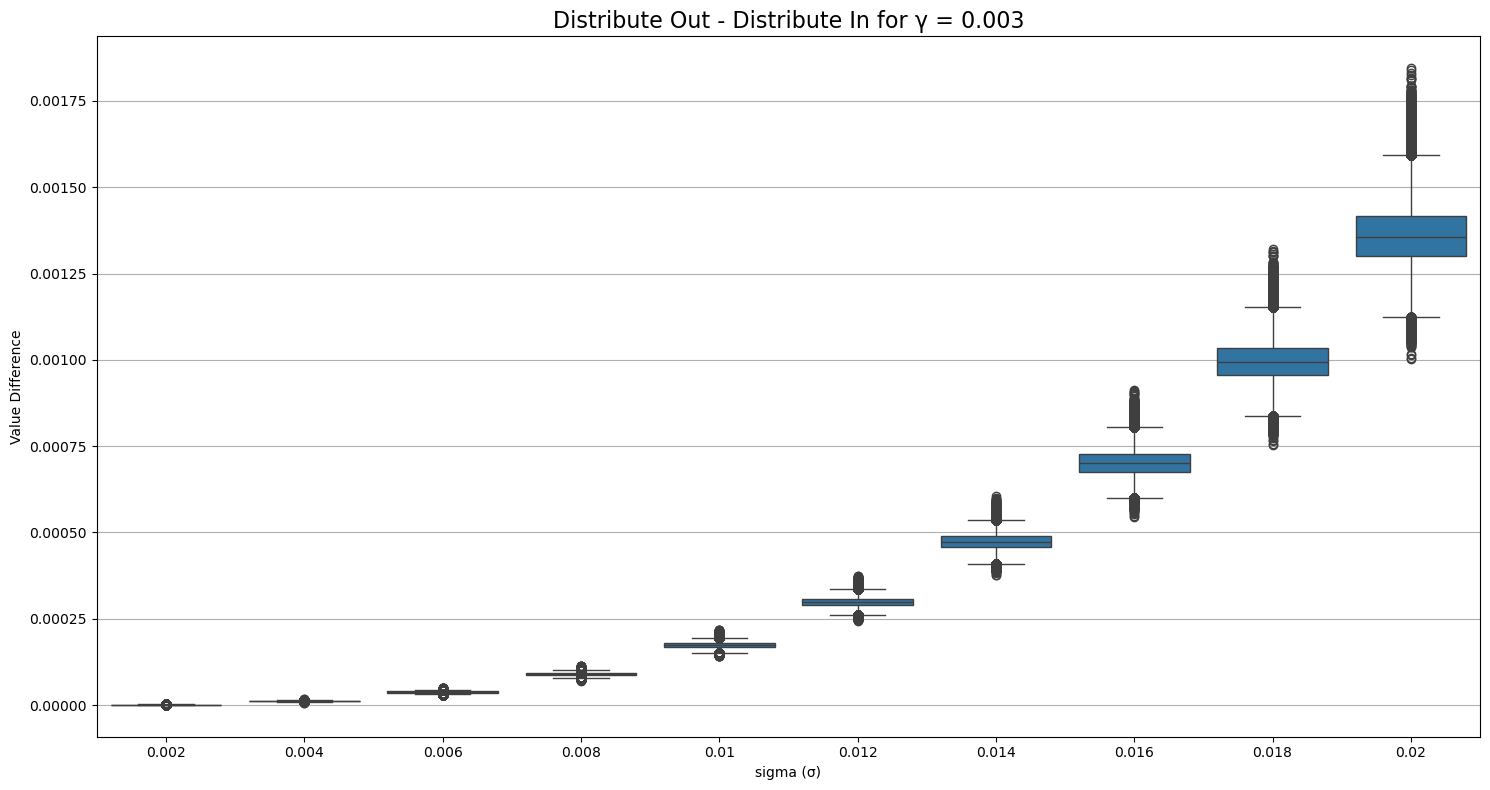

In [5]:

path = '/home/shiftpub/Dynamic_AMM/inf_step_exp/mc_approach/jit_simulation_results/20250412_205257'
gamma_value = 0.003  # Change this to your desired sigma value
create_boxplots_wrt_gamma(gamma_value, path)


In [1]:
import pandas as pd
import os
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def create_boxplots_wrt_sigma(sigma_value, path, output_dir="plots"):
    """Create a single boxplot for a specific gamma value using efficient Polars operations.
    
    Parameters:
    -----------
    gamma_value : float
        The gamma value to filter data for
    path : str
        Path to the directory containing parquet files
    output_dir : str
        Directory to save the output plot
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Find all chunk files
    chunk_files = sorted([f for f in os.listdir(path) 
                         if f.startswith('combined_simulation_results_epoch') and f.endswith('.parquet')])
    
    # Initialize empty lists to store the differences
    plot_data = {
        'sigma': [],
        'diff_dis_out_in': [],
        'diff_re_out_in': [],
        'diff_dis_out_re_out': [],
        'diff_dis_in_re_in': []
    }
    
    # Process each chunk separately
    for chunk in chunk_files:
        # Read and process one chunk at a time
        df = pl.scan_parquet(os.path.join(path, chunk)).filter(pl.col('sigma') == sigma_value)
        
        # Calculate derived values
        df = df.with_columns([
            (pl.col('final_x') * pl.col('final_price') + pl.col('final_y') + pl.col('fees_out')).alias('vout_dis'),
            (pl.col('final_x') * pl.col('final_price') + pl.col('final_y') + pl.col('fees_inc')).alias('vinc_dis'),
            (pl.col('final_xout') * pl.col('final_price') + pl.col('final_yout')).alias('vout_re'),
            (pl.col('final_xinc') * pl.col('final_price') + pl.col('final_yinc')).alias('vinc_re')
        ])
        
        # Calculate differences
        df = df.with_columns([
            (pl.col('vout_dis') - pl.col('vinc_dis')).alias('diff_dis_out_in'),
            (pl.col('vout_re') - pl.col('vinc_re')).alias('diff_re_out_in'),
            (pl.col('vout_dis') - pl.col('vout_re')).alias('diff_dis_out_re_out'),
            (pl.col('vinc_dis') - pl.col('vinc_re')).alias('diff_dis_in_re_in')
        ])
        
        # Select only the needed columns and collect
        chunk_data = df.select(['gamma', 'diff_dis_out_in', 'diff_re_out_in', 
                              'diff_dis_out_re_out', 'diff_dis_in_re_in']).collect()
        
        # Append to plot data
        for col in plot_data:
            plot_data[col].extend(chunk_data[col].to_list())
    
    # Convert to pandas only once for plotting
    plot_df = pd.DataFrame(plot_data)
    
    # Get unique gamma values for tick labels
    unique_sigmas = sorted(plot_df['gamma'].unique())
    tick_positions = np.arange(len(unique_sigmas))
    tick_labels = [f'{sigma:.3f}' if i % 3 == 0 else '' for i, sigma in enumerate(unique_sigmas)]
    
    # Create the plot
    plt.figure(figsize=(15, 8))
    plt.title(f'Distribute Out - Distribute In for γ = {gamma_value}', fontsize=16)
    
    # Create single boxplot
    sns.boxplot(data=plot_df, x='gamma', y='diff_dis_out_in')
    plt.xlabel('gamma (γ)')
    plt.ylabel('Value Difference')
    plt.grid(True, axis='y')
    plt.xticks(tick_positions)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save the plot
    plt.savefig(f"{output_dir}/boxplot_sigma_{gamma_value}.png", dpi=500)
    
    plt.show()

In [3]:

path = '/home/shiftpub/Dynamic_AMM/inf_step_exp/mc_approach/jit_simulation_results/20250412_205257'

df = pd.read_parquet(path)

df.columns


: 

In [2]:

path = '/home/shiftpub/Dynamic_AMM/inf_step_exp/mc_approach/jit_simulation_results/20250412_205257'
sigma_value = 0.02  # Change this to your desired sigma value
create_boxplots_wrt_sigma(sigma_value, path)


ColumnNotFoundError: "sigma" not found